# Exploratory Data Analysis 
## Table of Contents

- [1. Introduction](#intro)
- [2. Preparation](#P0)
  - [2.1 Import the datasets](#P01)
- [3. Data Understanding](#P1)
  - [3.1 General Exploration](#P11)
    - [3.1.1 Shape and dtypes](#P111)
    - [3.1.2 Missing values](#P112)
    - [3.1.3 Duplicates](#P113)
  - [3.2 Univariate Analysis](#P12)
    - [3.2.1 Categorical Features](#P121)
    - [3.2.2 Numerical Features](#P122)
  - [3.3 Multivariate Analysis](#P13)
    - [3.3.1 Most viewed](#P131)
- [4. Preprocessing Analysis](#P14)


# <font color='#ff6ca4' size=6>1. Introduction</font> <a class="anchor" id="intro"></a>

This notebook explores the song lyrics dataset to understand genre patterns, data quality issues, and the main signals relevant for classification. It also highlights the key cleaning and preprocessing steps necessary before deeper analysis and modeling.


# <font color='#ff6ca4' size=6>2. Preparation</font> <a class="anchor" id="P0"></a>
  
[Back to TOC](#toc)


### 2.1 Import the datasets <a class="anchor" id="P01"></a>


In [3]:
#pip install matplotlib
#pip install seaborn 

Importing needed libraries

In [30]:
%pip install nltk Unidecode python-dotenv better-profanity

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import importlib, utils
from utils import get_info_batch, get_song_info,fix_translation_artists

Loading the training dataset

In [6]:
df_train = pd.read_csv('data/train.csv')
df_train.shape

(134967, 8)

We load the training data and set aside 20% for validation before preprocessing.

# <font color='#ff6ca4' size=6>3. Data Understanding</font> <a class="anchor" id="P1"></a>
  

[Back to TOC](#toc)

### 3.1 General Exploration

#### 1.1.1 Shape and dtypes <a class="anchor" id="P111"></a>
Checking the dataset shape, dtypes, and the overall minimum and maximum values of the numeric features.


In [7]:
df_train.info()
df_train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134967 entries, 0 to 134966
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   title     134965 non-null  object
 1   tag       134967 non-null  object
 2   artist    134967 non-null  object
 3   year      134967 non-null  int64 
 4   views     134967 non-null  int64 
 5   features  134967 non-null  object
 6   lyrics    134967 non-null  object
 7   id        134967 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 8.2+ MB


,year,views,id
count,134967.000000,1.349670e+05,1.349670e+05
mean,2009.467537,3.413344e+03,3.593871e+06
std,46.287743,4.192449e+04,2.323217e+06
min,1.000000,0.000000e+00,2.800000e+01
25%,2008.000000,2.200000e+01,1.414202e+06
50%,2015.000000,8.900000e+01,3.547995e+06
75%,2019.000000,4.730000e+02,5.600458e+06
max,2024.000000,3.604497e+06,7.882826e+06


We will fix the inconsistency of having `year` stored as a string by converting it to a proper date type and having the minimum year as 1.

#### 1.1.2 Missing values <a class="anchor" id="P112"></a>


In [11]:
print(df_train.isnull().sum())

title       2
tag         0
artist      0
year        0
views       0
features    0
lyrics      0
id          0
dtype: int64


Checking if there are any empty text lyrics


In [12]:
# Checking empty and missing review texts
print("missing text lyrics:", df_train['lyrics'].isnull().sum())
print("empty text lyrics:", (df_train['lyrics'].str.strip() == '').sum())

missing text lyrics: 0
empty text lyrics: 0


#### 1.1.3 Duplicates <a class="anchor" id="P113"></a>


Duplicated rows

In [13]:
# checking duplicates across the entire row
full_row_duplicates = df_train.duplicated().sum()
print(f"full-row duplicates: {full_row_duplicates}")

full-row duplicates: 0


Duplicated Lyrics

In [14]:
# checking duplicate and empty lyrics, including possible label conflicts

lyrics_duplicate_counts = df_train.groupby('lyrics', dropna=False).agg(
    row_count=('id', 'size'),
    genre_count=('tag', 'nunique'),
)
duplicate_lyrics_groups = lyrics_duplicate_counts[lyrics_duplicate_counts['row_count'] > 1]
conflicting_duplicate_groups = duplicate_lyrics_groups[duplicate_lyrics_groups['genre_count'] > 1]
empty = (df_train['lyrics'].fillna('').str.strip() == '').sum()

print(f"duplicate lyric groups: {len(duplicate_lyrics_groups)}")
print(f"duplicate rows beyond first: {int((duplicate_lyrics_groups['row_count'] - 1).sum())}")
print(f"groups with conflicting genres: {len(conflicting_duplicate_groups)}")
print(f"rows in conflicting groups: {int(conflicting_duplicate_groups['row_count'].sum())}")
print(f"empty songs: {empty}")

duplicate lyric groups: 165
duplicate rows beyond first: 178
groups with conflicting genres: 13
rows in conflicting groups: 26
empty songs: 0


There may be rows that have the same lyrics but are not exactly duplicated rows. These can include remixes, instrumentals, and other near-duplicate versions. To handle this, we will try to identify the original songs and keep only those. This will be addressed in the preprocessing phase.

In [15]:
# rows whose lyrics appear more than once so we can inspect the duplicates
duplicated_lyrics_rows = df_train[
    df_train.duplicated(subset=['lyrics'], keep=False)
].sort_values('lyrics')

print(f"rows with duplicated lyrics: {len(duplicated_lyrics_rows)}")
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 100):
    display(duplicated_lyrics_rows.head(10))  # Display the first 10 rows of duplicated lyrics

rows with duplicated lyrics: 343


,title,tag,artist,year,views,features,lyrics,id
14594,Damage Ive Done Moby Sad Gospel mix,pop,The Heads,2015,14,{},"""There's buzzin' and ringin' in my ear\nAnd I wonder where do I go from here\nThe moments missed...",1442530
111409,Damage Ive Done Sound/Bisquit vocal mix,pop,The Heads,2015,12,{},"""There's buzzin' and ringin' in my ear\nAnd I wonder where do I go from here\nThe moments missed...",1214596
16236,Phillis Wheatley’s “On Being Brought from Africa to America”,misc,ChrisApap,2014,112,{},"'Twas mercy brought me from my Pagan land,\nTaught my benighted soul to understand\nThat there's...",518757
71910,Phillis Wheatley’s “On Being Brought from Africa to America”,misc,Dr. Katy Evans,2014,20,{},"'Twas mercy brought me from my Pagan land,\nTaught my benighted soul to understand\nThat there's...",365464
22751,Fingertips Part 1 Second Pressing,rb,Stevie Wonder,1963,56,{},"'Yeah'\n'Yeah'\n\nLadies and gentlemen, now I'm going to do a song\nTaken from my album, 'The Ja...",3767965
113161,Fingertips Part 1 First Pressing,pop,Stevie Wonder,1963,679,{},"'Yeah'\n'Yeah'\n\nLadies and gentlemen, now I'm going to do a song\nTaken from my album, 'The Ja...",837043
120909,Somebodys Gettin It,pop,Johnnie Taylor,1976,662,{},(CHORUS)\nSomebody's getting it\nSomebody's getting your love\nSomebody's getting it\nSomebody's...,1116229
8060,Somebodys Gettin It instrumental,pop,Johnnie Taylor,2015,28,{},(CHORUS)\nSomebody's getting it\nSomebody's getting your love\nSomebody's getting it\nSomebody's...,1315400
32527,Radio Hardcore - Crystal Lake Radio Edit,pop,ItaloBrothers,2015,40,{},(Radio Harcore)\nTurn on your radio and choose a frequency\nWe are On-Air all over the world to ...,2200514
40683,Radio hardcore - jasper remix,pop,ItaloBrothers,2015,43,{},(Radio Harcore)\nTurn on your radio and choose a frequency\nWe are On-Air all over the world to ...,2082236


note: The two duplicate counts are different because they measure different things. `duplicated(subset=['lyrics'])` counts only the repeated entries after the first one, while `duplicated(subset=['lyrics'], keep=False)` marks every row belonging to a duplicated lyric group. For example, if the same lyric appears 3 times, the first count returns 2 and the second returns 3.

In [16]:
#analysing the longest lyrics + 100 longest lyrics and comparing to the shortest ones


In [17]:
#getting the list of unique artist so we can take the non musicians
print(df_train['artist'].nunique())

print(df_train['artist'].unique().tolist())

74916
['Tony Molina', 'Reece Lett', 'Elliot (DNK)', 'Katie Armiger', 'John Campbell Munro', 'HoustonBlake', 'Della Marie', 'YRM Bear', 'Lil_Sauce_Goblin', 'Tom Robinson', 'Taj Ahkel', 'Lewis Del Mar', '2shanez', 'YOUNG DIAMOND', 'Reel Big Fish', 'Swift (Band)', 'Kuinn', 'Stephen Marley', 'The Aubreys', 'blackbear', 'X-Sinner', 'As I Lay Dying', 'Hercules & Love Affair', 'Ty Segall', 'Ricky Van Shelton', 'Martin the Misfit', 'Johnny Mathis', 'Current Joys', 'Jerry.C [UpToNoGood]', 'Nu Deja-Vu', 'Arber Lutolli', 'Emi Meyer', 'Tally Hall', 'Lune (SVE)', 'Maycoabarrios', 'Bruisers', 'AdzMilli', 'The Oak Ridge Boys', 'Is0kenny', 'Cleveland Bound Death Sentence', 'Significantly', 'Cinder Road', 'Fellwarden', 'The Neverending Mixtape', 'Aaron Malone', 'Demolition Train', '888 Blue', 'Morrissey', 'Andrews Right', 'Everything Everything', 'Standing on the Corner', '3rd Wave', 'Josh Ritter', 'Verse Simmonds', 'Dana Lyons', 'Linda Eder', 'Nameless', 'Bass Astral x Igo', 'Kenny Bands', 'Ihsahn', '

## 3.2 Univariate Analysis <a class="anchor" id="P12"></a>


### 1.2.1 Categorical Features <a class="anchor" id="P121"></a>


#### Genre distribution ('tag') and class balance <a class="anchor" id="P1211"></a>


In [18]:
print(df_train['tag'].value_counts()) #checking what genres we have and how many songs per genre


tag
pop        55742
rap        38584
rock       25332
rb          6203
misc        5640
country     3466
Name: count, dtype: int64


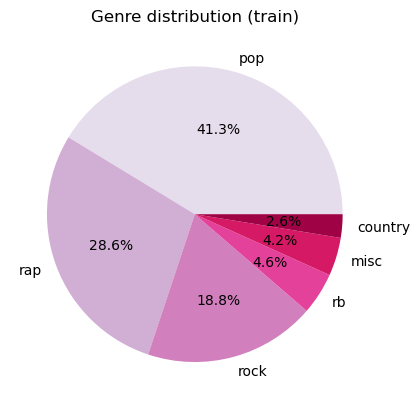

In [19]:
# Checking genre balance in the training dataset

palette = sns.color_palette('PuRd', n_colors=df_train['tag'].nunique())
df_train['tag'].value_counts().plot.pie(autopct ='%1.1f%%', ylabel = '', colors=palette)
plt.title('Genre distribution (train)')
plt.show()

The dataset contains six genres: `country`, `misc`, `pop`, `rap`, `rb`, and `rock`. The class distribution is not perfectly balanced, with some genres appearing much more frequently than others. This means the training data is dominated by a few classes, which can bias the model toward predicting the majority genres more often. In practice, this suggests that we should be careful with evaluation metrics and consider class-weighting or resampling strategies later in the modeling pipeline. The imbalance is also important because it may affect how we interpret performance across genres, especially for the minority classes.

#### Distribution of lyrics by genre <a class="anchor" id="P1212"></a>


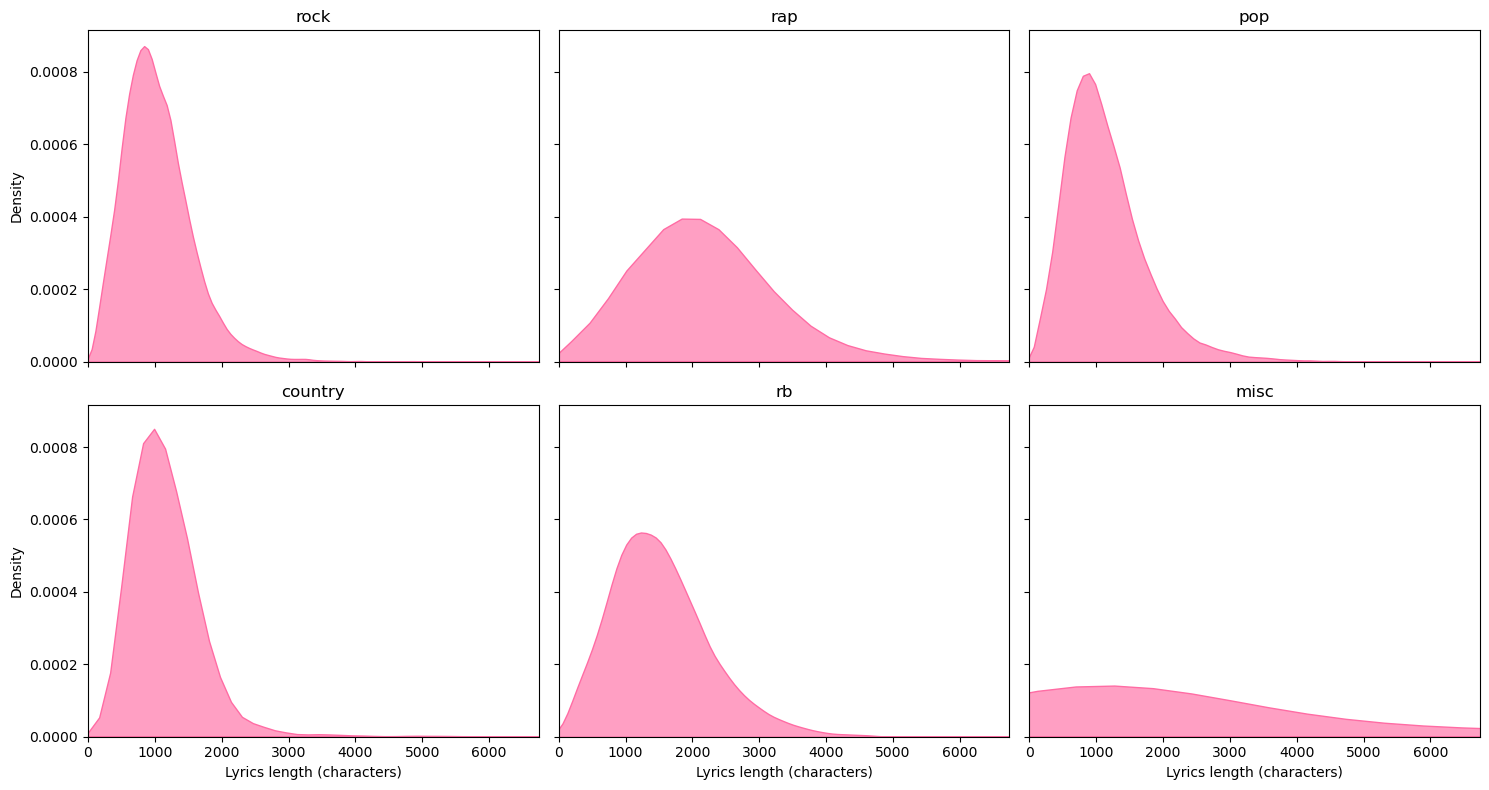

In [20]:
# distributions of lyrics size per music genre

tags = df_train['tag'].unique()
df_train['lyrics_length'] = df_train['lyrics'].str.len()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
pink = '#ff6ca4'

for ax, tag in zip(axes.flatten(), tags):
    subset = df_train[df_train['tag'] == tag]
    sns.kdeplot(data=subset, x='lyrics_length', ax=ax, fill=True, color=pink, alpha=0.65)
    ax.set_title(tag)
    ax.set_xlabel('Lyrics length (characters)')

plt.xlim(0, df_train['lyrics_length'].quantile(0.99))  # clip long tail
plt.tight_layout()
plt.savefig('lyrics_length_by_tag.png', dpi=150)
plt.show()

#### Artist count and frequency analysis <a class="anchor" id="P1213"></a>


In [21]:
artists = df_train['artist'].unique().tolist()#getting the list of unique artist so we can later deal with the non musicians
print(f"Total unique artists: {len(artists)}")

Total unique artists: 74916


In [22]:

# Top 10 most frequent artists in the training set
top_artists = df_train['artist'].value_counts().head(10)
display(top_artists)

artist
Genius English Translations    555
The Grateful Dead               86
Emily Dickinson                 75
Abraham Lincoln                 59
OCTOBERSFULLMOON                58
Lil B                           52
Holy Bible (KJV)                50
Gucci Mane                      49
KIDZ BOP Kids                   49
Charles Dickens                 48
Name: count, dtype: int64

We analyzed the `artist` variable by counting how many songs each artist appears with in the training data.

This is useful to check whether the dataset is dominated by a few artists, whether some artists are overrepresented, and whether there may be artist-level leakage across train/test splits or across genres. It also helps us spot repeated artists that could distort model training if not handled carefully.

We also identified that the most frequent artist is actually a translator rather than an artist in the musical sense, so those songs need to be assigned to their corresponding actual artist before we can draw meaningful conclusions about artist-level patterns. This is important because otherwise the artist counts would be misleading and could distort the analysis of artist imbalance and potential leakage.

In short, this analysis gives us a quick view of artist imbalance and provides a first signal for downstream checks such as duplicate artists, cross-genre artist distribution, and possible data leakage.

#### Features Count

In [23]:
# 'features' looks like {A,B,"C D"}: count items, treating quoted names as one item
feature_count = df_train['features'].str.findall(r'"(?:[^"\\]|\\.)*"|[^,{}"]+').str.len()

zero_features = (feature_count == 0).sum()
one_feature = (feature_count == 1).sum()
more_than_one_feature = (feature_count > 1).sum()

print(f"Songs with 0 features: {zero_features}")
print(f"Songs with exactly 1 feature: {one_feature}")
print(f"Songs with more than 1 feature: {more_than_one_feature}")


Songs with 0 features: 111928
Songs with exactly 1 feature: 18265
Songs with more than 1 feature: 4774


#### Top 10 most viewd songs

In [24]:
top_10_songs = (
    df_train.nlargest(10, 'views')[['title', 'views']]
    .reset_index(drop=True)
)

display(top_10_songs)

,title,views
0,Hit Em Up,3604497
1,V. 3005,3325127
2,Plain Jane Remix,3235312
3,Dusk Till Dawn,3033507
4,Nice For What,2942444
5,Energy,2781485
6,Broccoli,2660782
7,​hot girl bummer,2613320
8,Love on the Brain,2223025
9,Hope,2185037


#### Year distribution and consistency <a class="anchor" id="P1222"></a>

Here we examine the distribution of publication years to detect inconsistencies, suspicious values, and data quality issues. This helps us decide whether invalid entries should be corrected or removed before modeling.


In [25]:
raw_year = pd.read_csv('data/train.csv', usecols=['year'])['year']

# Handle years stored either as numbers or date strings
year_num = pd.to_numeric(raw_year, errors='coerce')
date_year = pd.to_datetime(raw_year, errors='coerce').dt.year
year_num = year_num.fillna(date_year).dropna().astype(int)

songs_per_year = year_num.value_counts().sort_index()

display(songs_per_year.rename('song_count').to_frame())
print(f"Unique years: {year_num.nunique()}")

,song_count
year,
1,45
3,1
4,1
6,1
7,1
...,...
2020,14027
2021,12368
2022,2707


Unique years: 282


Here we can see that there are many inconsistent year values such as `1`, `3`, `4`, and other abnormal entries. These values are likely corrupted, missing, or incorrectly parsed, so we need to identify which songs belong to those records and reassign them to the correct year during preprocessing.

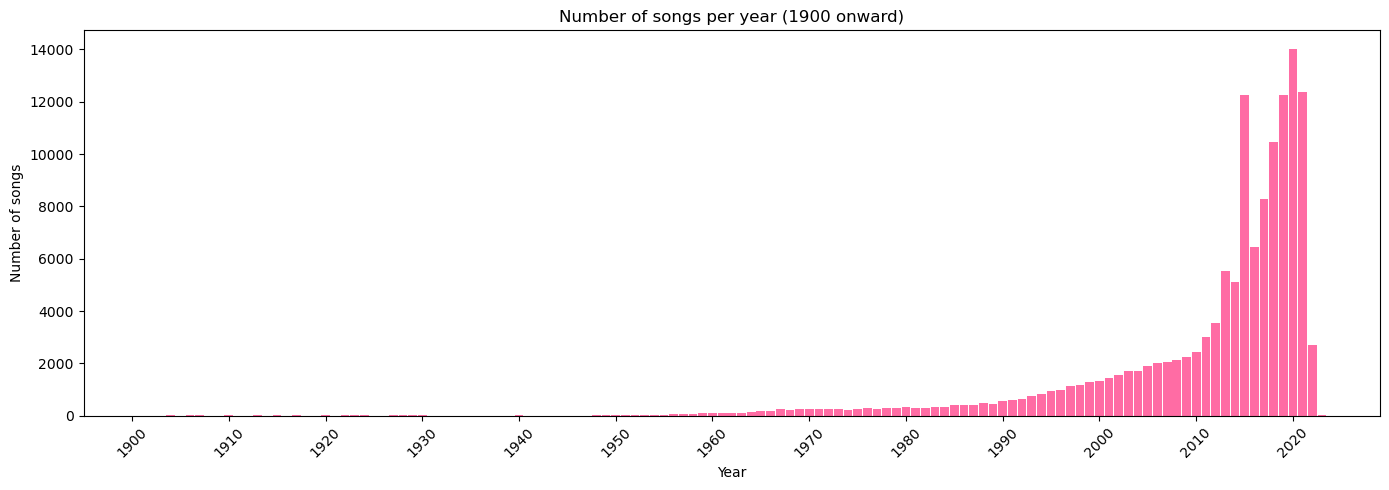

In [26]:
# Clean the year field and keep only realistic values
year_series = pd.read_csv('data/train.csv', usecols=['year'])['year'].astype(str).str.strip()

year_num = pd.to_numeric(year_series, errors='coerce')
date_year = pd.to_datetime(year_series, errors='coerce').dt.year

clean_year = year_num.fillna(date_year)
clean_year = clean_year[(clean_year >= 1900) & (clean_year <= 2030)].astype(int)

years_to_plot = clean_year
year_counts = years_to_plot.value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.bar(year_counts.index, year_counts.values, color=pink, width=0.9)
decade_ticks = range(1900, ((year_counts.index.max() // 10) + 1) * 10, 10)
plt.xticks(decade_ticks, rotation=45)
plt.xlim(1895, year_counts.index.max() + 5)
plt.title('Number of songs per year (1900 onward)')
plt.xlabel('Year')
plt.ylabel('Number of songs')
plt.tight_layout()
plt.show()

For this visualization, we restricted the data to songs from 1900 onward solely to make the year distribution easier to inspect. This is only a plotting choice; whether and how to handle songs from before 1900 will be decided and implemented during preprocessing.

### 1.2.3 Text caracteristics

We chose to emphasize this univariate analysis because examining lyrical characteristics (such as vocabulary, repetition, and profanity) helps show how the lyrics differ across genres and which textual patterns may be useful for genre classification.

##### vocabulary per genre

,avg_unique_words
tag,
misc,312.8
rap,180.9
rb,105.2
country,95.8
pop,89.7
rock,87.7


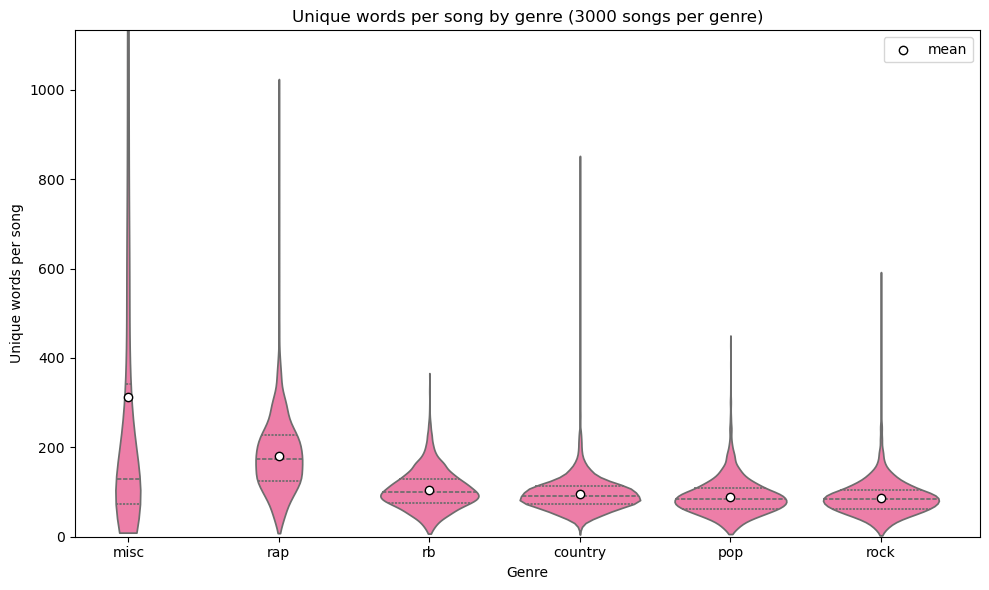

In [27]:
#vocabulary per genery 

# 3000 random songs per genre so every genre is compared on equal footing
sample_df = df_train.groupby('tag').sample(n=3000, random_state=42).copy()

# lowercase, drop [Chorus]-style annotations, keep only words
words = sample_df['lyrics'].str.lower().str.replace(r'\[.*?\]', ' ', regex=True).str.findall(r"\b\w+\b")
sample_df['word_count'] = words.str.len()
sample_df['unique_word_count'] = words.apply(lambda w: len(set(w)))

mean_unique = sample_df.groupby('tag')['unique_word_count'].mean().sort_values(ascending=False)
display(mean_unique.round(1).rename('avg_unique_words').to_frame())

fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=sample_df, x='tag', y='unique_word_count', order=mean_unique.index,
               color=pink, inner='quartile', cut=0, ax=ax)
ax.scatter(range(len(mean_unique)), mean_unique.values, color='white', edgecolor='black', zorder=3, label='mean')
ax.set_ylim(0, sample_df['unique_word_count'].quantile(0.99))  # clip long tail
ax.set_title('Unique words per song by genre (3000 songs per genre)')
ax.set_xlabel('Genre')
ax.set_ylabel('Unique words per song')
ax.legend()
plt.tight_layout()
plt.show()



The table and violin plot compare the average number of **distinct words per song** across 3,000 sampled songs per genre. In this sample, **misc** has the largest average vocabulary (312.8 unique words per song), while **rock** has the smallest (87.7). This is a raw count, so longer lyrics can contain more unique words; it measures vocabulary size per song, not vocabulary density.

##### TTR Score

,avg_ttr
tag,
misc,0.512
rock,0.462
rap,0.434
pop,0.425
country,0.424
rb,0.367


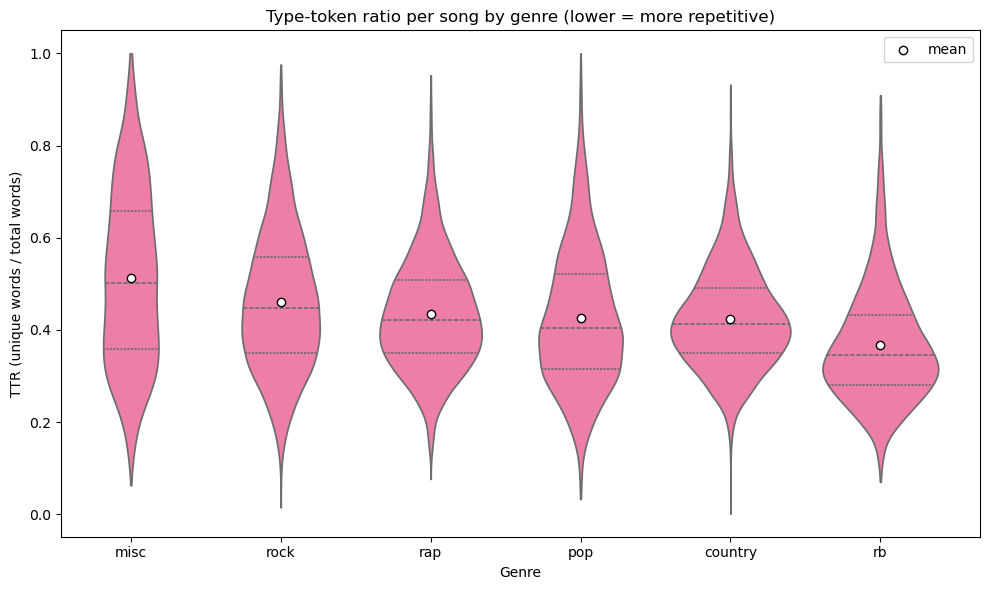

In [28]:
#Repetitive score TTR
sample_df['ttr'] = sample_df['unique_word_count'] / sample_df['word_count'].replace(0, np.nan)

mean_ttr = sample_df.groupby('tag')['ttr'].mean().sort_values(ascending=False)
display(mean_ttr.round(3).rename('avg_ttr').to_frame())

fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=sample_df, x='tag', y='ttr', order=mean_ttr.index,
               color=pink, inner='quartile', cut=0, ax=ax)
ax.scatter(range(len(mean_ttr)), mean_ttr.values, color='white', edgecolor='black', zorder=3, label='mean')
ax.set_title('Type-token ratio per song by genre (lower = more repetitive)')
ax.set_xlabel('Genre')
ax.set_ylabel('TTR (unique words / total words)')
ax.legend()
plt.tight_layout()
plt.show()



The **type-token ratio (TTR)** is the number of unique words (types) divided by the total number of words (tokens) in a song. It ranges from 0 to 1: higher values mean a larger share of the lyrics' words are distinct, while lower values indicate more repetition. The table shows the mean of each song's TTR for each genre. **R&B (rb)** has the lowest mean (0.367, or 36.7%), so it is the most repetitive by this measure; **misc** has the highest (0.512, or 51.2%), suggesting the greatest lexical variety. TTR can also be affected by song length, so these are comparisons within this sample rather than definitive measures of a genre.

460 profane word forms found in the sample


,pct_explicit,avg_profane_per_100_words
tag,,
rap,88.47,2.75
misc,49.93,0.59
rb,44.83,0.75
rock,35.30,0.57
country,30.97,0.35
pop,29.47,0.42


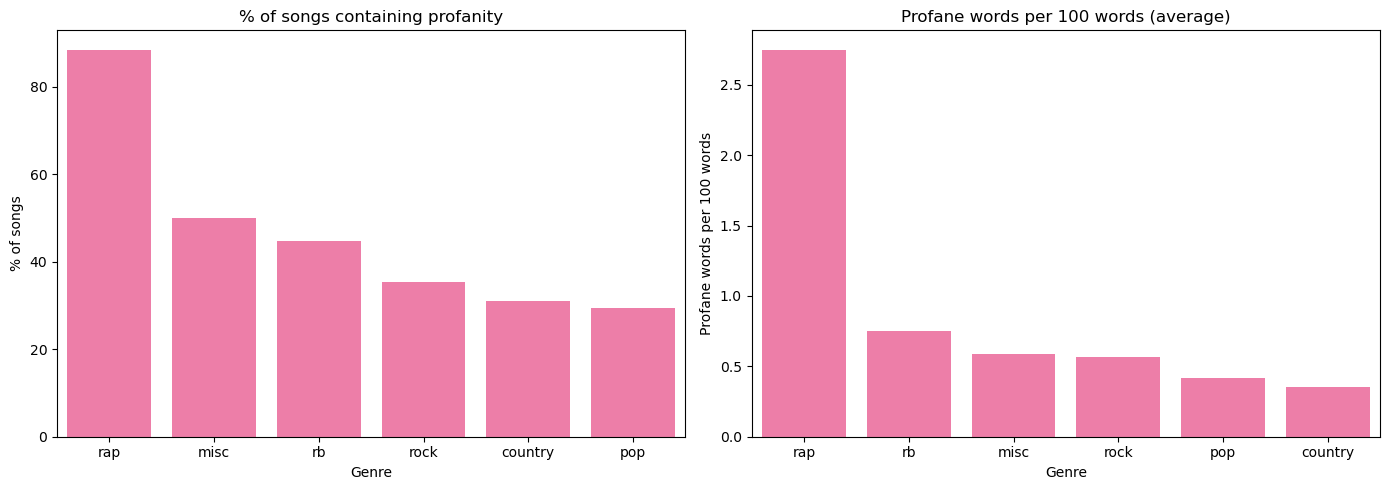

In [32]:


# Profanity score
from better_profanity import profanity

profanity.load_censor_words()
profanity.add_censor_words(['hoe', 'hoes', 'thot', 'thots', 'nigguh', 'bitchy', 'mf', 'mfs', 'fuckboy', 'fuckboys', 'shiit'])

# check each distinct word once instead of every word of every song ('words' comes from the vocabulary cell)
vocab = set(w for song in words for w in song)
profane_vocab = {w for w in vocab if not w.isdigit() and profanity.contains_profanity(w)}  # the default list flags a few bare numbers
print(f"{len(profane_vocab)} profane word forms found in the sample")

sample_df['profane_count'] = words.apply(lambda song: sum(w in profane_vocab for w in song))
sample_df['has_profanity'] = sample_df['profane_count'] > 0
sample_df['profanity_per_100_words'] = 100 * sample_df['profane_count'] / sample_df['word_count'].replace(0, np.nan)

profanity_by_genre = sample_df.groupby('tag').agg(
    pct_explicit=('has_profanity', lambda s: 100 * s.mean()),
    avg_profane_per_100_words=('profanity_per_100_words', 'mean'),
).round(2).sort_values('pct_explicit', ascending=False)
display(profanity_by_genre)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=profanity_by_genre.index, y=profanity_by_genre['pct_explicit'], color=pink, ax=axes[0])
axes[0].set_title('% of songs containing profanity')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('% of songs')
profanity_rate_order = profanity_by_genre['avg_profane_per_100_words'].sort_values(ascending=False).index
sns.barplot(x=profanity_by_genre.index, y=profanity_by_genre['avg_profane_per_100_words'], order=profanity_rate_order, color=pink, ax=axes[1])
axes[1].set_title('Profane words per 100 words (average)')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Profane words per 100 words')
plt.tight_layout()
plt.show()



The first column is the percentage of sampled songs containing at least one word flagged by the profanity detector; the second is the average number of flagged words per 100 words. **Rap** is highest on both measures: 88.47% of songs contain flagged words, averaging 2.75 per 100 words. **Pop** has the smallest share of songs containing any flagged words (29.47%), while **country** has the lowest average rate (0.35 per 100 words). These are detector-based estimates: results depend on its word list (including the added terms) and do not represent an official content rating.

##### Genius formating 

In [33]:
#Genius formating 

import re

annotation_re = re.compile(r'\[([^\]]*)\]')

sample_df['n_annotations'] = sample_df['lyrics'].str.count(annotation_re.pattern)
sample_df['has_annotations'] = sample_df['n_annotations'] > 0
sample_df['has_chorus_tag'] = sample_df['lyrics'].str.contains(r'\[(?:chorus|hook|refrain)', case=False, regex=True)

annotations_by_genre = sample_df.groupby('tag').agg(
    pct_with_annotations=('has_annotations', lambda s: 100 * s.mean()),
    pct_with_chorus_tag=('has_chorus_tag', lambda s: 100 * s.mean()),
    avg_annotations_per_song=('n_annotations', 'mean'),
).round(2)
display(annotations_by_genre)

# group annotations by type: "[Verse 2: Drake]" -> "verse"
annotation_types = (sample_df['lyrics'].str.findall(annotation_re.pattern).explode().dropna()
                    .str.lower().str.split(':').str[0].str.replace(r'[\d\s]+$', '', regex=True).str.strip())
display(annotation_types.value_counts().head(15).rename('count').to_frame())


,pct_with_annotations,pct_with_chorus_tag,avg_annotations_per_song
tag,,,
country,52.63,43.33,3.15
misc,20.77,5.93,2.56
pop,32.37,26.50,2.16
rap,68.90,50.17,3.94
rb,63.60,55.03,4.17
rock,40.87,32.70,2.59


,count
lyrics,
verse,15719
chorus,13858
bridge,2583
outro,2394
pre-chorus,2371
hook,2261
?,2206
intro,1895
,820



This code examines how lyrics are formatted with bracketed section labels (such as `[Verse]` or `[Chorus]`) in the sampled songs. It groups songs by genre and reports the percentage with any annotation, the percentage with a chorus/hook/refrain label, and the average number of annotations per song. These measures help compare how consistently lyrics are structured and labeled across genres; they reflect the available lyric annotations, not necessarily the actual musical structure.

In this sample, **R&B (`rb`)** has the highest annotation coverage (63.60%), chorus-tag rate (55.03%), and average annotations per song (4.17). **Rap** also has high coverage (68.90%, the highest share with any annotation) and the second-highest chorus-tag rate (50.17%) and average count (3.94). **Country** is notable: 52.63% of songs have annotations and its chorus-tag rate is 43.33%. **Misc** has the lowest annotation and chorus-tag percentages (20.77% and 5.93%), while **pop** has the fewest annotations per song on average (2.16).

##### Music Structure

,line_count,avg_line_length,repeated_line_rate
tag,,,
country,31.93,37.66,0.25
misc,49.09,190.48,0.07
pop,35.33,37.48,0.26
rap,55.07,49.20,0.18
rb,45.80,33.82,0.27
rock,32.65,33.97,0.25


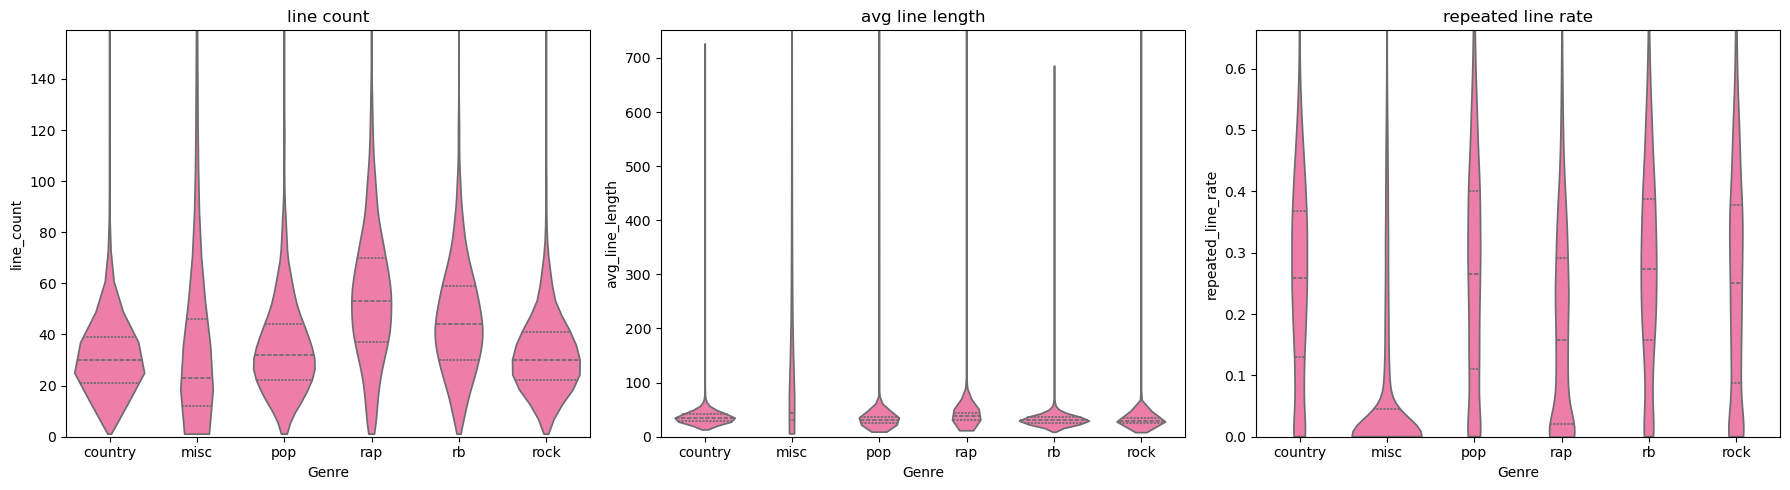

In [34]:
#Structure of the music

def structure_stats(lyrics):
    text = annotation_re.sub('', lyrics)
    lines = [l.strip() for l in text.split('\n') if l.strip()]
    if not lines:
        return pd.Series({'line_count': 0, 'avg_line_length': np.nan, 'repeated_line_rate': np.nan})
    return pd.Series({
        'line_count': len(lines),
        'avg_line_length': np.mean([len(l) for l in lines]),
        'repeated_line_rate': 1 - len(set(lines)) / len(lines),
    })

structure_metrics = ['line_count', 'avg_line_length', 'repeated_line_rate']
sample_df[structure_metrics] = sample_df['lyrics'].apply(structure_stats)
display(sample_df.groupby('tag')[structure_metrics].mean().round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, structure_metrics):
    sns.violinplot(data=sample_df, x='tag', y=metric, color=pink, inner='quartile', cut=0, ax=ax)
    ax.set_ylim(0, sample_df[metric].quantile(0.99))  # clip long tail
    ax.set_title(metric.replace('_', ' '))
    ax.set_xlabel('Genre')
plt.tight_layout()
plt.show()



This code removes bracketed Genius annotations (for example, `[Verse 2]`) before measuring the lyrics' line structure. For each song, it calculates the number of non-empty lines, the average number of characters per line, and the repeated-line rate (the share of lines that repeat an earlier line). It then reports genre averages and plots the song-level distributions. These are simple proxies for lyrical structure, not a complete analysis of musical form.

In the sample, **rap** has the highest average line count (55.07), while **rock** has the lowest (32.65). **Misc** has by far the longest average lines (190.48 characters) and the lowest repeated-line rate (0.07), suggesting that its lyrics may be formatted differently or contain long blocks of text; interpret this category cautiously. Among the other genres, **R&B (`rb`)** has the highest repeated-line rate (0.27), with pop at 0.26, while rap is lower (0.18). A rate of 0.27 means about 27% of non-empty lines are repeats under this calculation.

## 3.3 Multivariate Analysis <a class="anchor" id="P13"></a>


### 3.3.1 Most viewed <a class="anchor" id="P131"></a>


#### Views vs. genres ('tag') <a class="anchor" id="P1311"></a>


,median_views,average_views
tag,,
country,153.0,2067.404501
pop,107.0,2252.091403
rock,98.0,2726.447655
rb,91.0,6256.137030
rap,71.0,5479.774466
misc,20.0,1539.413652


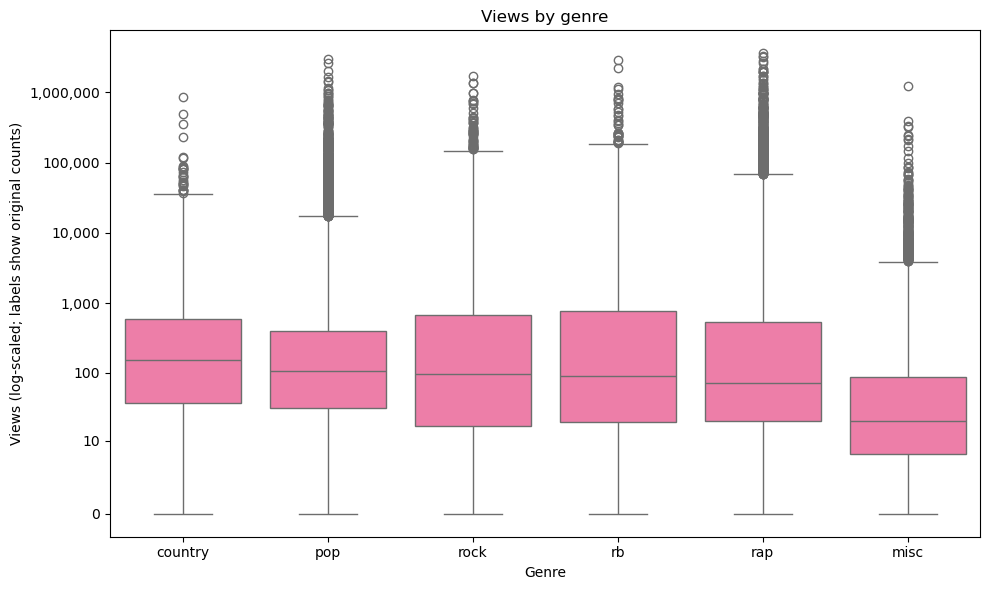

In [35]:
# Plot log-transformed views, with y-axis tick labels shown as original view counts
plot_df = df_train[['tag', 'views']].copy()
plot_df['log_views'] = np.log1p(plot_df['views'])
view_ticks = [0] + [10**i for i in range(1, 8)]
view_ticks = [v for v in view_ticks if v <= plot_df['views'].max()]

views_by_genre = (
    plot_df.groupby('tag')['views']
    .agg(median_views='median', average_views='mean')
    .sort_values('median_views', ascending=False)
)
display(views_by_genre)
genre_order = views_by_genre.index

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=plot_df,
    x='tag',
    y='log_views',
    order=genre_order,
    color=pink,
    showfliers=True,
    ax=ax
)

ax.set_yticks(np.log1p(view_ticks))
ax.set_yticklabels([f'{v:,}' for v in view_ticks])
ax.set_title('Views by genre')
ax.set_xlabel('Genre')
ax.set_ylabel('Views (log-scaled; labels show original counts)')
plt.tight_layout()
plt.show()

The boxplot shows many high-view outliers across genres. These extreme values inflate the mean, so average views should be interpreted with caution; the median provides a more robust measure of typical views. We will assess and handle these outliers during preprocessing.

#### Views vs. artists <a class="anchor" id="P1312"></a>


In [36]:
top_10_artists = (
    df_train.groupby('artist', as_index=False)['views']
    .sum()
    .nlargest(10, 'views')
    .reset_index(drop=True)
)

display(top_10_artists)

,artist,views
0,Drake,14539018
1,Eminem,6705635
2,2Pac,5893474
3,Genius English Translations,5410296
4,Taylor Swift,5112263
5,XXXTENTACION,4496096
6,The Weeknd,4072403
7,Childish Gambino,3916886
8,A$AP Ferg,3721960
9,A Boogie wit da Hoodie,3168133


#### Genres by decade <a class="anchor" id="P1313"></a>


tag,country,misc,pop,rap,rb,rock
decade,,,,,,
1900,0,61,3,0,0,0
1910,0,66,8,0,0,0
1920,24,49,21,0,9,0
1930,18,19,19,0,2,1
1940,12,15,37,0,3,0
1950,76,26,264,0,32,32
1960,264,29,960,0,146,289
1970,293,48,1330,8,276,679
1980,168,37,2218,138,177,1015


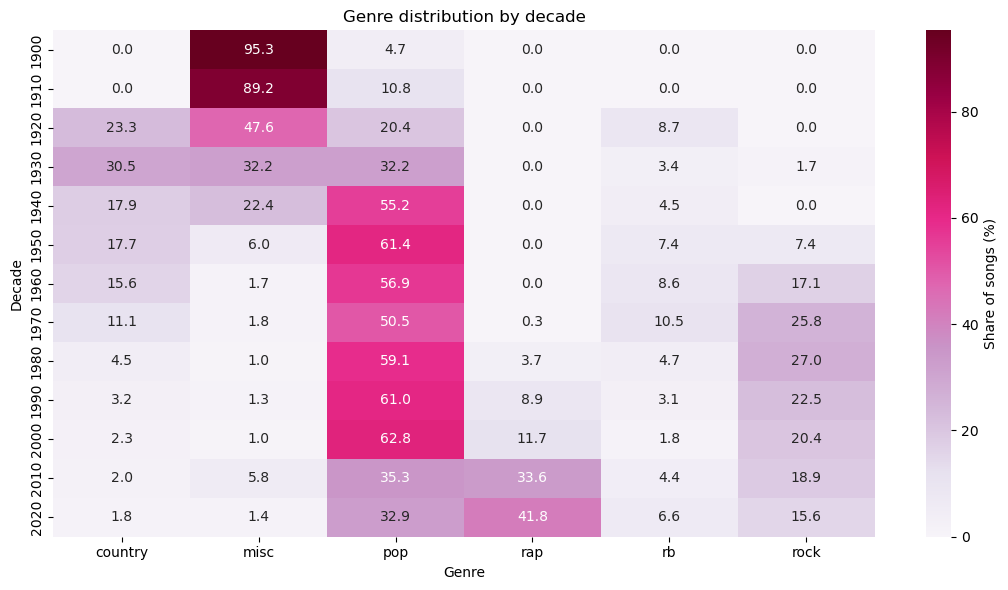

In [37]:
year_genre_df = df_train.loc[clean_year.index, ['tag']].copy()
year_genre_df['year'] = clean_year
year_genre_df['decade'] = (year_genre_df['year'] // 10) * 10

decade_genre_counts = pd.crosstab(year_genre_df['decade'], year_genre_df['tag'])
decade_genre_pct = decade_genre_counts.div(decade_genre_counts.sum(axis=1), axis=0) * 100

display(decade_genre_counts)

plt.figure(figsize=(11, 6))
sns.heatmap(
    decade_genre_pct,
    annot=True,
    fmt='.1f',
    cmap='PuRd',
    cbar_kws={'label': 'Share of songs (%)'}
)
plt.title('Genre distribution by decade')
plt.xlabel('Genre')
plt.ylabel('Decade')
plt.tight_layout()
plt.show()

The decade-level genre mix shows that `misc` was the largest share in the 1900s, 1910s, and 1920s. In the 1930s, `misc` and `pop` were tied at 32.2% each. `pop` had the largest share from the 1940s through the 2010s, while `rap` led in the 2020s.

Looking at each genre's largest share within a decade, `country` peaked in the 1930s, `misc` in the 1900s, `pop` in the 2000s, `rap` in the 2020s, `rb` in the 1970s, and `rock` in the 1980s. These are within-decade proportions, not raw release counts. In raw counts, every genre has its most records in the 2010s, reflecting how heavily that decade is represented in this dataset.

#### Top 3 artists per genre <a class="anchor" id="P1314"></a>


In [38]:
# Top 3 artists per genre by number of songs
top_artists_per_genre = (
    df_train.groupby(['tag', 'artist'])
    .size()
    .rename('song_count')
    .reset_index()
    .sort_values(['tag', 'song_count', 'artist'], ascending=[True, False, True])
    .groupby('tag')
    .head(3)
    .reset_index(drop=True)
)

display(top_artists_per_genre)

,tag,artist,song_count
0,country,Willie Nelson,42
1,country,Dolly Parton,31
2,country,George Jones,30
3,misc,Emily Dickinson,74
4,misc,Abraham Lincoln,59
5,misc,Holy Bible (KJV),50
6,pop,Genius English Translations,309
7,pop,KIDZ BOP Kids,49
8,pop,Frank Sinatra,44
9,rap,Genius English Translations,163


The current top three artists in each genre by number of songs are:

- **Country:** Willie Nelson (42), Dolly Parton (31), and George Jones (30)
- **Misc:** Emily Dickinson (74), Abraham Lincoln (59), and Holy Bible (KJV) (50)
- **Pop:** Genius English Translations (309), KIDZ BOP Kids (49), and Frank Sinatra (44)
- **Rap:** Genius English Translations (163), OCTOBERSFULLMOON (56), and Lil B (51)
- **R&B:** Genius English Translations (30), Chris Brown (28), and James Brown (27)
- **Rock:** The Grateful Dead (75), Genius English Translations (52), and Tendon Levey (45)

These rankings are provisional because some songs are incorrectly credited to Genius English Translations, which is a translator rather than the performing artist. Until we correct those credits during preprocessing, the artist counts and ranking positions will not be accurate.

# <font color='#ff6ca4' size=6>4. Preprocessing Analysis</font> <a class="anchor" id="P14"></a>


In [ ]:
from sklearn.model_selection import train_test_split # estou refazendo istooooooooooo 

In [69]:
X = df_train.drop(columns=['tag'])
y = df_train['tag']

In [70]:
# Primeiro Split: separar 20% para Teste e guardar 80% para (Train + Validation)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y # Mantém a proporção das tags igual nos splits
)

In [71]:
# Segundo Split: dos 80% (X_temp), tiramos 25% para a Validação 
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.25, 
    random_state=42, 
    stratify=y_temp
)

In [72]:
from preprocessing import preprocess_data

# Depois do split, processamos cada conjunto separadamente para evitar leakage.
# X_train, y_train, X_val, y_val, X_test, y_test já existem no notebook.

train_df = X_train.join(y_train.rename('tag'))
val_df = X_val.join(y_val.rename('tag'))
test_df = X_test.join(y_test.rename('tag'))

train_df = preprocess_data(train_df)
val_df = preprocess_data(val_df)
test_df = preprocess_data(test_df)

X_train = train_df.drop(columns=['tag'])
y_train = train_df['tag']

X_val = val_df.drop(columns=['tag'])
y_val = val_df['tag']

X_test = test_df.drop(columns=['tag'])
y_test = test_df['tag']

c:\Users\maria\Documents\Universidade\Text Mining\Text-Mining-\preprocessing.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  prepared = prepared[~prepared["title"].str.contains(variations_pattern, na=False, regex=True)]
c:\Users\maria\Documents\Universidade\Text Mining\Text-Mining-\preprocessing.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  prepared = prepared[~prepared["title"].str.contains(variations_pattern, na=False, regex=True)]
c:\Users\maria\Documents\Universidade\Text Mining\Text-Mining-\preprocessing.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  prepared = prepared[~prepared["title"].str.contains(variations_pattern, na=False, regex=True)]


### 4.1.1 Correcting  artist names

In [73]:
from utils import fix_translation_artists

for split_df in (train_df, val_df, test_df):
    translated_mask = split_df['artist'].fillna('').str.contains(
        'Genius|Translation', case=False, na=False
    )
    if not translated_mask.any():
        continue

    translated_rows = split_df.loc[translated_mask, ['id', 'title']]
    title_artists = (
        fix_translation_artists(translated_rows)
        .drop_duplicates('id')
        .set_index('id')['artist']
    )
    row_ids = split_df.loc[translated_mask, 'id']
    corrected_artists = row_ids.map(title_artists)
    split_df.loc[translated_mask, 'artist'] = corrected_artists.combine_first(
        split_df.loc[translated_mask, 'artist']
    )

### 4.1.2 Correcting invalid years 

In [81]:
from utils import get_info_batch

split_frames = (train_df, val_df, test_df)
invalid_year_masks = [
    pd.to_numeric(split_df['year'], errors='coerce') < 1900
    for split_df in split_frames
]
invalid_year_ids = pd.concat([
    split_df.loc[year_mask, 'id']
    for split_df, year_mask in zip(split_frames, invalid_year_masks)
]).dropna().unique()

if len(invalid_year_ids) > 0:
    year_metadata = get_info_batch(invalid_year_ids, release_date=True)
    release_years = pd.to_datetime(
        year_metadata['release_date'], errors='coerce'
    ).dt.year

    for split_df, year_mask in zip(split_frames, invalid_year_masks):
        row_years = split_df.loc[year_mask, 'id'].map(release_years).dropna()
        split_df.loc[row_years.index, 'year'] = row_years.astype(int)

X_train = train_df.drop(columns=['tag'])
y_train = train_df['tag']
X_val = val_df.drop(columns=['tag'])
y_val = val_df['tag']
X_test = test_df.drop(columns=['tag'])
y_test = test_df['tag']

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\maria\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\maria\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\maria\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


RuntimeError: Genius API key not found. Add GENIUS_API_KEY=your_key to a .env file in the project folder, then run this cell again.

### 4.1.1 Checking if the preprocessing functions are working

In [77]:
print('train shape:', X_train.shape, y_train.shape)
print('val shape:', X_val.shape, y_val.shape)
print('test shape:', X_test.shape, y_test.shape)

train_df[['id', 'title', 'artist', 'year', 'tag']].head()

train shape: (77266, 8) (77266,)
val shape: (25705, 8) (25705,)
test shape: (25700, 8) (25700,)


train shape: (77266, 8) (77266,)
val shape: (25705, 8) (25705,)
test shape: (25700, 8) (25700,)


,id,title,artist,year,tag
54189,6307947,With You,DC Young Fly & Fetty Wap,2020,rap
55448,6400577,Too High,Goyrd,2021,rap
84487,4268613,Breathe,Stealing Sheep,2019,pop
123503,4326603,Old Customer,Fiziedeen,2019,rap
8850,4271904,Runnin,Sey,2018,rap


In [82]:
print('Year counts in train_df:')
print(train_df['year'].value_counts(dropna=False).sort_index())

print('\nTop 20 singers in train_df:')
print(train_df['artist'].value_counts(dropna=False).head(20))

print('\nAPI release dates found:', year_metadata['release_date'].notna().sum(), 'of', len(year_metadata))
remaining_invalid = sum(
    (pd.to_numeric(split_df['year'], errors='coerce') < 1900).sum()
    for split_df in split_frames
)
print('Years still below 1900:', remaining_invalid)

Year counts in train_df:
year
1         32
6          1
7          1
9          1
14         1
        ... 
2019    7103
2020    8187
2021    7156
2022    1577
2023       5
Name: count, Length: 252, dtype: int64

Top 20 singers in train_df:
artist
Emily Dickinson         48
Abraham Lincoln         34
OCTOBERSFULLMOON        33
Gucci Mane              30
Charles Dickens         30
KIDZ BOP Kids           30
William Shakespeare     30
Holy Bible (KJV)        28
Thomas Hardy            28
Lil B                   27
Vybz Kartel             27
Lil Wayne               27
Willie Nelson           27
Frank Sinatra           26
Guided by Voices        26
Mario William Vitale    24
Dolly Parton            24
Frank Zappa             24
Tendon Levey            24
YOUNG DIAMOND           23
Name: count, dtype: Int64

API release dates found: 0 of 645
Years still below 1900: 645
